### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Step 2: Constant

In [3]:
FACE_PROTO = './data/AgePrediction/opencv_face_detector.pbtxt'
FACE_MODEL = './data/AgePrediction/opencv_face_detector_uint8.pb'
AGE_PROTO = './data/AgePrediction/age_deploy.prototxt'
AGE_MODEL = './data/AgePrediction/age_net.caffemodel'
AGE_LIST = ['(0-2)', '(4-6)', '(8-12)', '(15-20)', '(25-32)', '(38-43)']
IMG_PATH = './data/AgePrediction/kid1.jpg'
MODEL_MEAN_VALUES = (78.4263377603, 87.7689143744, 114.895847746)

### Step 3: Load Model

In [4]:
face_net = cv2.dnn.readNetFromTensorflow(FACE_MODEL, FACE_PROTO)
age_net = cv2.dnn.readNetFromCaffe(AGE_PROTO, AGE_MODEL)

### Step 4: Detecting Faces

In [5]:
def detect_faces(net, frame, conf_threshold=0.7):
    frame_height, frame_width, frame_channels = frame.shape
    blob = cv2.dnn.blobFromImage(
        frame,
        1.0,
        (300, 300),
        [104, 117, 123],
        False,
        False
    )
    net.setInput(blob)
    detections = net.forward()
    face_boxes = list()
    for i in range(frame_channels):
        confidence = detections[0, 0, i, 2]
        if confidence > conf_threshold:
            x1 = int(detections[0, 0, i, 3] * frame_width)
            y1 = int(detections[0, 0, i, 4] * frame_height)
            x2 = int(detections[0, 0, i, 5] * frame_width)
            y2 = int(detections[0, 0, i, 6] * frame_height)
            face_boxes.append([x1, y1, x2, y2])
            cv2.rectangle(
                frame, 
                (x1, y1), 
                (x2, y2), 
                (0, 255, 0),
                int(round(frame_height/150)),
                8
            )
    return frame, face_boxes

### Step 5: Predicting Age

In [6]:
def predict_age(face, net):
    blob = cv2.dnn.blobFromImage(
        face,
        1.0,
        (227, 227),
        MODEL_MEAN_VALUES,
        swapRB=False
    )
    net.setInput(blob)
    age_preds = net.forward()
    age = AGE_LIST[age_preds[0].argmax()]
    return age

### Step 6: Processing Image

In [11]:
def process_image(image_path):
    frame = cv2.imread(image_path)

    if frame is None:
        print(f'Error: Image not found at {image_path}')
        return

    frame, face_boxes = detect_faces(face_net, frame)

    for (x1, y1, x2, y2) in face_boxes:
        face = frame[
            max(0, y1-20): min(y2+20, frame.shape[0]-1),
            max(0, x1-20): min(x2+20, frame.shape[1]-1)            
        ]
        age = predict_age(face, age_net)
        cv2.putText(
            frame, 
            f'Age: {age}', 
            (x1, y1-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 255, 255),
            2,
            cv2.LINE_AA
        )
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

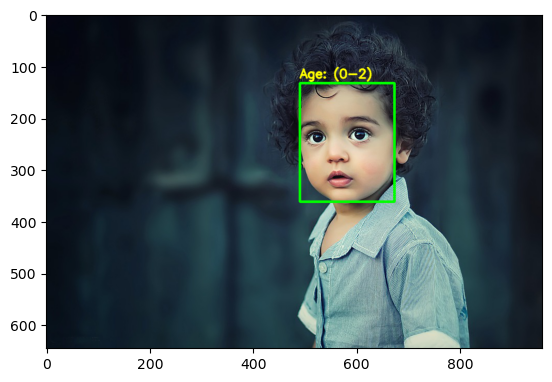

In [12]:
process_image(IMG_PATH)